In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=0


In [ ]:
import os
import json
import scipy.interpolate
import numpy as np
import torch
import torchaudio
import torchaudio.transforms as T
#import torchaudio.functional as F
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from torchaudio.transforms import Resample, MelSpectrogram, AmplitudeToDB
from qwen_vl_utils import process_vision_info

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from collections import defaultdict

import json
from copy import deepcopy
from transformers import BitsAndBytesConfig
from PIL import Image
from decord import VideoReader, cpu
import logging
from tqdm import tqdm
from faster_whisper import WhisperModel
from vllm import LLM, SamplingParams
from transformers import AutoModel, AutoTokenizer, AutoModelForSpeechSeq2Seq, AutoModelForVision2Seq, AutoProcessor, pipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [2]:
def plot_images_grid(images, cols=3):
    """
    Plots a list of PIL images in a tight grid with minimal whitespace.
    """
    n_images = len(images)
    if n_images == 0:
        print("No images to display.")
        return

    # Calculate rows needed
    rows = int(np.ceil(n_images / cols))
    
    # 1. Get aspect ratio of the first image to set optimal figsize
    w, h = images[0].size
    aspect_ratio = h / w
    
    # 2. Calculate figsize: Width is fixed (e.g., 15), Height adapts to aspect ratio
    # We add a tiny bit of buffer (0.1) for titles if needed
    fig_width = 15
    fig_height = fig_width * aspect_ratio * (rows / cols)
    
    # 3. Create figure with constrained_layout (better than tight_layout)
    # gridspec_kw sets the internal gaps to 0
    fig, axes = plt.subplots(
        rows, cols, 
        figsize=(fig_width, fig_height),
        gridspec_kw={'wspace': 0.05, 'hspace': 0.05}, # Small gap for separation
        constrained_layout=True
    )
    
    # Handle single image or single row case
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < n_images:
            ax.imshow(images[i])
            # Optional: Remove title to save more vertical space
            # ax.set_title(f"Frame {i}", fontsize=8) 
            ax.axis('off')
        else:
            ax.axis('off')

    plt.show()

def cluster_images_gmm(image_features_tensor, K=3):
    """
    Clusters image features using Gaussian Mixture Model and selects key frames
    
    Returns:
        list: Indices of selected key frames sorted by original temporal order
    """
    features_np = image_features_tensor.cpu().numpy()  # Shape: (num_images, feature_dim)
    
    # 2. Configure GMM with improved parameters
    gmm = GaussianMixture(
        n_components=K,
        covariance_type='full',  # Try 'tied' covariance first
        max_iter=100,            # Increased iterations
        n_init=5,               # More initializations
        init_params='kmeans',    # Better initialization
        random_state=42
    ).fit(features_np)

    # Get probabilities
    cluster_labels = gmm.fit_predict(features_np)
    probabilities = gmm.predict_proba(features_np)
    
    # 3. Build cluster map {cluster_id: [original_indices]}
    cluster_map = defaultdict(list)
    for idx, label in enumerate(cluster_labels):
        cluster_map[label].append(idx)
    
    # 4. Find closest sample to each cluster's mean
    key_frame_indices = []
    for cluster_id in range(K):
        original_indices = cluster_map.get(cluster_id, [])
        if not original_indices:
            continue  # Skip empty clusters (though GMM should avoid this)
        
        # Get cluster mean (GMM component mean)
        centroid = gmm.means_[cluster_id]
        
        # Calculate distances to centroid
        cluster_features = features_np[original_indices]
        distances = np.linalg.norm(cluster_features - centroid, axis=1)
        closest_idx_in_cluster = np.argmin(distances)
        key_frame_original_index = original_indices[closest_idx_in_cluster]
        key_frame_indices.append(key_frame_original_index)
    
    means = gmm.means_
    per_feature_variances = [np.diag(gmm.covariances_[k]) for k in range(K)]
    per_feature_std = [np.sqrt(v) for v in per_feature_variances]
    
    relevant_frames = []
    for k in range(K):
        diff = np.linalg.norm(features_np - means[k], axis=1)
        std = np.linalg.norm(per_feature_std[k])
        relevant_frames.append((np.where(diff <= std)[0].min(), np.where(diff <= std)[0].max()))

    # Sort the final key frame indices temporally
    key_frame_indices.sort()
    return key_frame_indices, cluster_labels, probabilities, relevant_frames

def visualize_clusters(features_tensor, cluster_labels, title="Cluster Visualization", 
                     key_indices=None, output_path=None, dimensions=2):
    """
    Visualize clustering results using PCA dimensionality reduction
    
    Args:
        features_tensor (torch.Tensor): (num_samples, ...) feature tensor
        cluster_labels (np.array): Cluster assignments for each sample
        title (str): Plot title
        key_indices (list): Indices of key frames to highlight
        output_path (str): Path to save the figure
        dimensions (int): 2D or 3D visualization
    """
    # Process features (average along sequence dimension if needed)
    features_np = features_tensor.cpu().numpy()
    
    # Apply PCA
    pca = PCA(n_components=dimensions)
    pca_result = pca.fit_transform(features_np)
    
    # Create figure
    if dimensions == 2:
        fig, ax = plt.subplots(figsize=(10, 6))
        sc = ax.scatter(pca_result[:,0], pca_result[:,1], 
                       c=cluster_labels, cmap='viridis', alpha=0.6)
        
        # Highlight key frames if provided
        if key_indices is not None:
            key_coords = pca_result[key_indices]
            ax.scatter(key_coords[:,0], key_coords[:,1], 
                      c='red', marker='X', s=100, edgecolor='black', 
                      label='Key Frames')

            # Add cluster index labels next to key frames
            for idx, (x, y) in enumerate(key_coords):
                label = cluster_labels[key_indices[idx]]
                ax.annotate(f'{label}', 
                           (x, y), 
                           textcoords='offset points',
                           xytext=(0,10),
                           ha='center',
                           color='black',
                           fontsize=8,
                           arrowprops=dict(arrowstyle="->", color='gray'))
        
        ax.set_title(title)
        plt.colorbar(sc)
        plt.legend()
        
    elif dimensions == 3:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(pca_result[:,0], pca_result[:,1], pca_result[:,2], 
                       c=cluster_labels, cmap='viridis', alpha=0.6)
        
        if key_indices is not None:
            key_coords = pca_result[key_indices]
            ax.scatter(key_coords[:,0], key_coords[:,1], key_coords[:,2], 
                      c='red', marker='X', s=100, edgecolor='black', 
                      label='Key Frames')
        
        ax.set_title(title)
        fig.colorbar(sc, ax=ax)
        ax.legend()
        
    else:
        raise ValueError("Dimensions must be 2 or 3")
    
    # Save or show
    if output_path:
        plt.savefig(output_path, bbox_inches='tight', dpi=300)
    else:
        plt.show()
    plt.close()

In [3]:
!ls /home/dexter/LLaVA-VLS/playground/demo

69118fe052fb155119d76733j1I4g7PP06.mp4	mallard-water.mp4
6911901d0b52d480daffcdf5OKs2mEUO06.mp4	man_flower_cat.mp4
6.mp4					moonwalk.mp4
cat_woman.mp4				QID80I1IRyI_heatmap.json
dark_cat.mp4				QID80I1IRyI.mp4
Eo_9CAjLoWM_fixed.mp4			Trim-C0.mp4
Eo_9CAjLoWM_heatmap.json		Trim-C2.mp4
Eo_9CAjLoWM.mp4				video_demo.py
irQLp-8PACA_heatmap.json		xU25MMA2N4aVtYay.mp4
irQLp-8PACA.mp4


## Load Video & Audio

In [4]:
video_id = "QID80I1IRyI"

path_wsl = f"/mnt/c/Users/dexter.neo/Desktop/LLMVS/{video_id}.mp4"
path_linux = f"/home/dexter/LLaVA-VLS/playground/demo/{video_id}.mp4"

# Check which one actually exists
if os.path.exists(path_wsl):
    url = path_wsl
    print(f"Found file in WSL path: {url}")
elif os.path.exists(path_linux):
    url = path_linux
    print(f"Found file in Linux path: {url}")
    
waveform, sample_rate = torchaudio.load(url)
waveform_mono = waveform[0]
duration_sec = waveform.shape[1] / sample_rate

print(f"Waveform shape: {waveform.shape}")
print(f"Sample rate: {sample_rate} Hz")

Found file in Linux path: /home/dexter/LLaVA-VLS/playground/demo/QID80I1IRyI.mp4
Waveform shape: torch.Size([2, 61286400])
Sample rate: 44100 Hz


In [5]:
#display(Audio(waveform_mono, rate=sample_rate))

In [7]:
model_id = "openai/whisper-large-v3-turbo"

# Initialize the pipeline
asr_pipeline = pipeline(
    "automatic-speech-recognition",
    model=model_id,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device=device,
    model_kwargs={"attn_implementation": "sdpa"}, # optimizations
)

transcripts = {}

Device set to use cuda


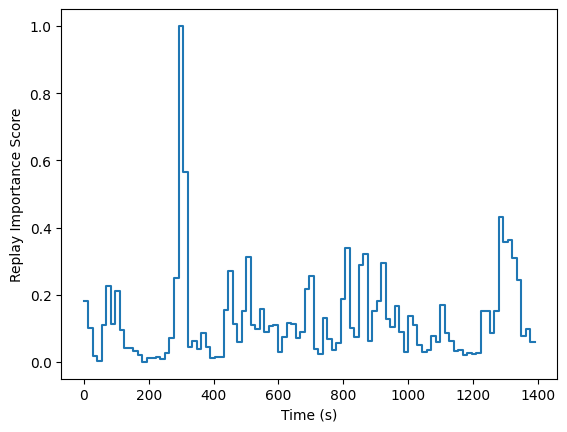

In [6]:
try:
    with open(f"/home/dexter/LLaVA-VLS/playground/demo/{video_id}_heatmap.json", 'r') as f:
        data = json.load(f)
except FileNotFoundError:
    with open(f"/mnt/c/Users/dexter.neo/Desktop/LLMVS/{video_id}.mp4", 'r') as f:
        data = json.load(f)

# 3. Prepare Data for Step Plot
times = [entry["start_time"] for entry in data] + [data[-1]["end_time"]]
values = [entry["value"] for entry in data] + [data[-1]["value"]]
plt.step(times, values, where="post", label="Heatmap Values")
plt.xlabel("Time (s)")
plt.ylabel("Replay Importance Score")
plt.show()

## Visual Captioning Model (MiniCPM VLM)

In [7]:
class QwenVLWrapper:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer

    def chat(self, msgs: str, **kwargs):
        image_inputs, video_inputs, video_kwargs = process_vision_info([msgs], return_video_kwargs=True, 
                                                                       image_patch_size=16,
                                                                       return_video_metadata=True)
        text = self.tokenizer.apply_chat_template(
            msgs,
            tokenize=False,
            add_generation_prompt=True
        )

        if video_inputs is not None:
            video_inputs, video_metadatas = zip(*video_inputs)
            video_inputs, video_metadatas = list(video_inputs), list(video_metadatas)
        else:
            video_metadatas = None

        inputs = self.tokenizer(text=[text], images=image_inputs, videos=video_inputs, video_metadata=video_metadatas, **video_kwargs, do_resize=False, return_tensors="pt")
        
        #model_inputs = self.tokenizer([text], return_tensors="pt").to("cuda")
        
        with torch.no_grad():
            generated_ids = self.model.generate(
                **inputs.to("cuda"),
                max_new_tokens=2048,
                do_sample=False,
                temperature=0.0
            )
        generated_ids_trimmed = [
            out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
            ]
        output_text = self.tokenizer.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
            )

        return output_text[0]

USE_BACKBONE = "Mini"
if "Mini" in USE_BACKBONE:
    print("Loading Caption Model (MiniCPM-V)...")
    caption_model = AutoModel.from_pretrained('/home/dexter/VideoRAG/.checkpoints/MiniCPM-V-2_6-int4', 
                    trust_remote_code=True,
                    device_map=device,
                    #_attn_implementation="flash_attention_2",
                    dtype=torch.bfloat16).eval()
    caption_tokenizer = AutoTokenizer.from_pretrained('/home/dexter/VideoRAG/.checkpoints/MiniCPM-V-2_6-int4', trust_remote_code=True)
else:
    print("Loading Caption Model (QWEN3-VL)...")
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16
    )
    
    caption_model = AutoModelForVision2Seq.from_pretrained(
            "Qwen/Qwen3-VL-8B-Instruct",
            device_map="cuda",
            quantization_config=quantization_config,
            dtype=torch.bfloat16,
            trust_remote_code=True).eval()
    
    caption_tokenizer = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct", pad_token='<|endoftext|>')
    caption_model = QwenVLWrapper(caption_model, caption_tokenizer)

[2026-01-30 10:32:43] INFO configuration_minicpm.py:92: vision_config is None, using default vision config


Loading Caption Model (MiniCPM-V)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [8]:
def batched_minicpm_inference(
        model, 
        tokenizer, 
        processor=None, 
        images=None, 
        max_slice_nums=1, 
        use_image_id=False, 
        max_inp_length=2048,
        msgs_template=None,
        system_prompt=None,
        **kwargs
    ):
    
        prompts_lists = []
        input_images_lists = []
    
        for img in images:
            msgs = deepcopy(msgs_template)
            if isinstance(msgs[0]["content"], str):
                msgs[0]["content"] = [img, msgs[0]["content"]]
                
            # Convert message content to the specific format MiniCPM expects: "(<image>./</image>)"
            # This flattens the list [Image, Text] into a single string with the placeholder
            current_images = []
            for i, msg in enumerate(msgs):
                if isinstance(msg["content"], list):
                    cur_content_text = []
                    for c in msg["content"]:
                        if isinstance(c, Image.Image):
                            current_images.append(c)
                            cur_content_text.append("(<image>./</image>)")
                        elif isinstance(c, str):
                            cur_content_text.append(c)
                    msg["content"] = "\n".join(cur_content_text)
                    
            if system_prompt:
                msgs.insert(0, {'role': 'system', 'content': system_prompt})
        
            prompt_str = processor.tokenizer.apply_chat_template(
                msgs, 
                tokenize=False, 
                add_generation_prompt=True
            )
            
            prompts_lists.append(prompt_str)
            input_images_lists.append(current_images)
        
        max_slice_nums = 1
        max_inp_length = 2048
        
        inputs = processor(
            prompts_lists, 
            input_images_lists, 
            max_slice_nums=max_slice_nums,
            use_image_id=False,
            return_tensors="pt", 
            max_length=max_inp_length
        ).to(caption_model.device)
        
        if "position_ids" not in inputs:
            batch_size, seq_len = inputs["input_ids"].shape
            # Create simple sequential positions [0, 1, 2, ... seq_len]
            inputs["position_ids"] = torch.arange(seq_len, dtype=torch.long, device=caption_model.device).unsqueeze(0).expand(batch_size, -1)
        
        if "image_sizes" in inputs:
            inputs.pop("image_sizes")
        
        with torch.inference_mode():
            outputs = caption_model(inputs, attention_mask=inputs["attention_mask"], output_hidden_states=True)
            logits = outputs.logits[:, -1, :]
            probs = torch.nn.functional.softmax(logits, dim=-1)
            vllm_embedding, vision_hidden_states = caption_model.get_vllm_embedding(inputs)
        
        # response = caption_tokenizer.batch_decode(probs.argmax(1))
        # confidence, response = probs.max(1)

        return probs, torch.vstack(vision_hidden_states).mean(1)

In [20]:
from torch.utils.data import Dataset, DataLoader

class VideoSegmentDataset(Dataset):
    def __init__(self, video_path, segment_length, width=1280, height=720):
        self.video_path = video_path
        self.segment_length = segment_length
        self.width = width
        self.height = height
        
        # Open once just to get FPS/Step logic, then close
        vr = VideoReader(video_path, ctx=cpu(0))
        self.fps = vr.get_avg_fps()
        self.step = int(self.fps * 1) 
        self.duration = len(vr) / self.fps
        self.scan_range = list(range(0, int(self.duration), segment_length))
        del vr

    def __len__(self):
        return len(self.scan_range)

    def __getitem__(self, idx):
        start_sec = self.scan_range[idx]
        end_sec = min(start_sec + self.segment_length, self.duration)
        
        # Open NEW reader for this process (Thread-safe)
        vr = VideoReader(self.video_path, ctx=cpu(0), width=self.width, height=self.height)
        
        start_frame = int(start_sec * self.fps)
        end_frame = int(end_sec * self.fps)
        indices = list(range(start_frame, end_frame, self.step))
        
        # Fast Decode + Convert to PIL
        batch_npy = vr.get_batch(indices).asnumpy()
        # "RGB" mode speeds up conversion slightly
        frames = [Image.fromarray(f, mode='RGB') for f in batch_npy]
        
        return frames, start_sec, end_sec


video_path = path_linux
vr = VideoReader(video_path, width=1280, height=720, ctx=cpu(0))
fps = 60
total_frames = len(vr)
duration = total_frames / fps
segment_length = 20  # seconds
step = int(fps)      # stride for 1 FPS sampling

dataset = VideoSegmentDataset(path_linux, segment_length)
dataloader = DataLoader(
        dataset, 
        batch_size=1, 
        shuffle=False, 
        num_workers=4, 
        prefetch_factor=2,
        collate_fn=lambda x: x[0] # Unpack batch dimension, we want the raw tuple
    )

In [21]:
# Variables
yes_token_id = caption_tokenizer.encode("Yes", add_special_tokens=False)[0]
no_token_id = caption_tokenizer.encode("No", add_special_tokens=False)[0]

processor = AutoProcessor.from_pretrained('/home/dexter/VideoRAG/.checkpoints/MiniCPM-V-2_6-int4', trust_remote_code=True)

prompt = (
    "Analyze these frames for text banners like 'First Blood', 'Double Kill', "
    "'Triple Kill', 'Quadra Kill', or 'Invincible'. "
    "If any of these are present, answer 'Yes'. Otherwise, answer 'No'. "
    "Do not provide any explanation."
)

prev_start_sec = -100
prev_end_sec = -100
hit_frames_segments = {}
all_hits = []
all_hits_confs = []
hidden_states_list = [] # Stores history

# --- 4. OPTIMIZED LOOP ---
# We iterate the DATALOADER now, not the range
for frames, start_sec, end_sec in tqdm(dataloader, desc="Processing Segments"):
    
    # Convert scalar tensors to python items if needed
    if isinstance(start_sec, torch.Tensor): start_sec = start_sec.item()
    if isinstance(end_sec, torch.Tensor): end_sec = end_sec.item()

    msgs_template = [{"role": "user", "content": prompt}]
    system_prompt = "You are a video game expert identifier."

    # Inference
    probs, hidden_states = batched_minicpm_inference(
        caption_model, 
        caption_tokenizer, 
        processor=processor, 
        images=frames, 
        msgs_template=msgs_template,
        system_prompt=system_prompt
    )

    # 1. Normalize Probs
    yes_no_probs = probs[:, [no_token_id, yes_token_id]]
    normalized_probs = yes_no_probs / yes_no_probs.sum(dim=-1, keepdim=True)
    segment_yes_scores = normalized_probs[:, 1].cpu()

    # 2. Hit Detection
    confidence, answer = probs.max(1)
    
    # Calculate mask
    is_hit = (answer == yes_token_id)
    
    if is_hit.sum() > 0:
        hit_mask = is_hit.cpu()
        num_frames = hit_mask.shape[0]
        
        # Create timestamp relative to start_sec
        # Note: 'indices' step logic in dataset = 1.5s, so we must map index to time
        # A simple approximation if fps is consistent:
        time_offsets = torch.arange(num_frames) * (dataset.step / fps)
        timestamp = (start_sec + time_offsets)[hit_mask]
        timestamp_conf = confidence[is_hit].cpu()
        
        all_hits.append(timestamp)

        # Print / Save Logic
        if start_sec == prev_end_sec:
            print(f"🔗 Extend: ({prev_start_sec}-{end_sec}) Conf: {timestamp_conf.mean():.2f}")
            hit_frames_segments[(prev_start_sec, end_sec)] = frames 
            prev_end_sec = end_sec
        else:
            print(f"🎯 New: ({start_sec}-{end_sec}) Conf: {timestamp_conf.mean():.2f}")
            hit_frames_segments[(start_sec, end_sec)] = frames
            prev_end_sec = end_sec
            prev_start_sec = start_sec

       

    # 4. Interpolate scores to match duration (seconds)
    expected_duration = int(end_sec - start_sec)
    if len(segment_yes_scores) != expected_duration:
        segment_yes_scores = torch.nn.functional.interpolate(
            segment_yes_scores.view(1, 1, -1), 
            size=expected_duration, 
            mode='linear', 
            align_corners=False
        ).view(-1)

    all_hits_confs.append(segment_yes_scores)    
    hidden_states_list.append(hidden_states.cpu())

Processing Segments:   0%|                                                                       | 0/70 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork i

🎯 New: (300-320) Conf: 0.75


Processing Segments:  40%|████████████████████████▊                                     | 28/70 [00:32<00:45,  1.08s/it]

🎯 New: (540-560) Conf: 0.75


Processing Segments:  50%|███████████████████████████████                               | 35/70 [00:40<00:37,  1.08s/it]

...

Processing Segments:  89%|██████████████████████████████████████████████████████▉       | 62/70 [01:08<00:08,  1.00s/it]

🎯 New: (1220-1240) Conf: 0.94


Processing Segments:  93%|█████████████████████████████████████████████████████████▌    | 65/70 [01:11<00:05,  1.00s/it]

🎯 New: (1280-1300) Conf: 0.92


Processing Segments: 100%|██████████████████████████████████████████████████████████████| 70/70 [01:15<00:00,  1.08s/it]


In [16]:
video_path = path_linux
vr = VideoReader(video_path, width=1280, height=720, ctx=cpu(0))
fps = vr.get_avg_fps()
total_frames = len(vr)
duration = total_frames / fps
segment_length = 20  # seconds
step = int(fps)      # stride for 1 FPS sampling

yes_token_id = caption_tokenizer.encode("Yes", add_special_tokens=False)[0]
no_token_id = caption_tokenizer.encode("No", add_special_tokens=False)[0]

prompt = (
    "Analyze these frames for text banners like 'First Blood', 'Double Kill', "
    "'Triple Kill', 'Quadra Kill', or 'Invincible'. "
    "If any of these are present, answer 'Yes'. Otherwise, answer 'No'. "
    "Do not provide any explanation."
)
processor = AutoProcessor.from_pretrained('/home/dexter/VideoRAG/.checkpoints/MiniCPM-V-2_6-int4', trust_remote_code=True)

# Loop through 20-second segments
# e.g., 0, 20, 40...
prev_start_sec = -100
prev_end_sec = -100
hit_frames_segments = {}
hit_frames_captions = {}
all_hits = []
all_hits_confs = []
hidden_states_list = []

for start_sec in tqdm(range(500, int(duration), segment_length), desc="Processing Segments"):
    
    # Calculate start/end frames for this segment
    start_frame = int(start_sec * fps)
    end_sec = min(start_sec + segment_length, duration)
    end_frame = int(end_sec * fps)
    
    indices = list(range(start_frame, end_frame, step))
    
    # FASTEST PART: Decord grabs all frames in one go
    batch_frames = vr.get_batch(indices).asnumpy()
    frames = [Image.fromarray(f) for f in batch_frames]

    
    # Define your prompt
    msgs_template = [{"role": "user", "content": prompt}]
    system_prompt = "You are a video game expert identifier."

    probs, hidden_states = batched_minicpm_inference(
        caption_model, 
        caption_tokenizer, 
        processor=processor, 
        images=frames, 
        max_slice_nums=1, 
        use_image_id=False, 
        max_inp_length=2048,
        msgs_template=msgs_template,
        system_prompt=system_prompt
    )
    # 1. Get Normalized "Yes" Probabilities
    yes_no_probs = probs[:, [no_token_id, yes_token_id]]
    normalized_probs = yes_no_probs / yes_no_probs.sum(dim=-1, keepdim=True)
    
    # Extract just column 1 ("Yes") and move to CPU
    # Shape is roughly [20] or [21] depending on FPS rounding
    segment_yes_scores = normalized_probs[:, 1].cpu()

    # 2. Hit Detection Logic (Binary Decisions)
    confidence, answer = probs.max(1)
    if sum(answer == yes_token_id) > 0:
        hit_mask = (answer.cpu() == yes_token_id)
        num_frames = hit_mask.shape[0]
        timestamp = torch.tensor([int(start_sec) + i for i in range(num_frames)])[hit_mask]
        timestamp_conf = confidence[hit_mask].cpu()
        
        all_hits.append(timestamp)
        
        if start_sec == prev_end_sec:
            print((prev_start_sec, end_sec), timestamp, timestamp_conf.mean())
            hit_frames_segments[(prev_start_sec, end_sec)] = frames 
            prev_end_sec = end_sec
        else:
            print((start_sec, end_sec), timestamp, timestamp_conf)
            hit_frames_segments[(start_sec, end_sec)] = frames
            prev_end_sec = end_sec
            prev_start_sec = start_sec
    
        # look back
        combined_feats = torch.nn.functional.normalize(torch.vstack(hidden_states_list), dim=1)
        sim_matrix = torch.mm(combined_feats, combined_feats.T)
        hit_indices = torch.where(hit_mask)[0][0]
        sim_to_hits = sim_matrix[:, hit_indices]
        print(sim_to_hits)
        hidden_states_list = []
        
    # 3. FIX: Interpolation / Length Correction
    # We must ensure this chunk has EXACTLY (end_sec - start_sec) data points
    expected_duration = int(end_sec - start_sec)
    
    if len(segment_yes_scores) != expected_duration:
        # Interpolate: needs [Batch, Channel, Length] input -> [1, 1, Current_Len]
        segment_yes_scores = torch.nn.functional.interpolate(
            segment_yes_scores.view(1, 1, -1), 
            size=expected_duration, 
            mode='linear', 
            align_corners=False
        ).view(-1) # Flatten back to 1D array

    # 4. Append the clean, fixed-length scores
    all_hits_confs.append(segment_yes_scores)
    hidden_states_list.append(hidden_states)

Processing Segments:   0%|                                                                       | 0/45 [00:00<?, ?it/s]Autotune Choices Stats:
{"num_choices": 8, "num_triton_choices": 7, "best_kernel": "convolution", "best_time": 0.6691840291023254, "best_triton_pos": 1, "best_triton_time": 1.0739840269088745, "best_triton_kernel": "triton_convolution2d_3", "best_triton_kernel_desc": "ALLOW_TF32=True, BLOCK_K=16, BLOCK_M=128, BLOCK_N=128, GROUPS=1, KERNEL_H=14, KERNEL_W=14, PADDING_H=0, PADDING_W=0, STRIDE_H=14, STRIDE_W=14, UNROLL=False, num_stages=2, num_warps=8"}
AUTOTUNE convolution(16x3x14x14448, 1152x3x14x14)
strides: [606816, 1, 43344, 3], [588, 1, 42, 3]
dtypes: torch.bfloat16, torch.bfloat16
  convolution 0.6692 ms 100.0% 
  triton_convolution2d_3 1.0740 ms 62.3% ALLOW_TF32=True, BLOCK_K=16, BLOCK_M=128, BLOCK_N=128, GROUPS=1, KERNEL_H=14, KERNEL_W=14, PADDING_H=0, PADDING_W=0, STRIDE_H=14, STRIDE_W=14, UNROLL=False, num_stages=2, num_warps=8
  triton_convolution2d_4 1.0889 m

RuntimeError: Error: accessing tensor output of CUDAGraphs that has been overwritten by a subsequent run. Stack trace: File "/home/dexter/.cache/huggingface/modules/transformers_modules/MiniCPM_hyphen_V_hyphen_2_6_hyphen_int4/modeling_navit_siglip.py", line 927, in torch_dynamo_resume_in_forward_at_909
    last_hidden_state = self.post_layernorm(last_hidden_state)
  File "/home/dexter/anaconda3/envs/VRAG/lib/python3.11/site-packages/accelerate/hooks.py", line 166, in new_forward
    output = module._old_forward(*args, **kwargs). To prevent overwriting, clone the tensor outside of torch.compile() or call torch.compiler.cudagraph_mark_step_begin() before each model invocation.

In [62]:
key_frame_indices, cluster_labels, probabilities, relevant_frames =  cluster_images_gmm(out.to(torch.float16), K=7)

/home/dexter/anaconda3/envs/VRAG/lib/python3.11/site-packages/sklearn/mixture/_gaussian_mixture.py:527: RuntimeWarning: overflow encountered in cast
  log_prob[:, k] = xp.sum(xp.square(y), axis=1)


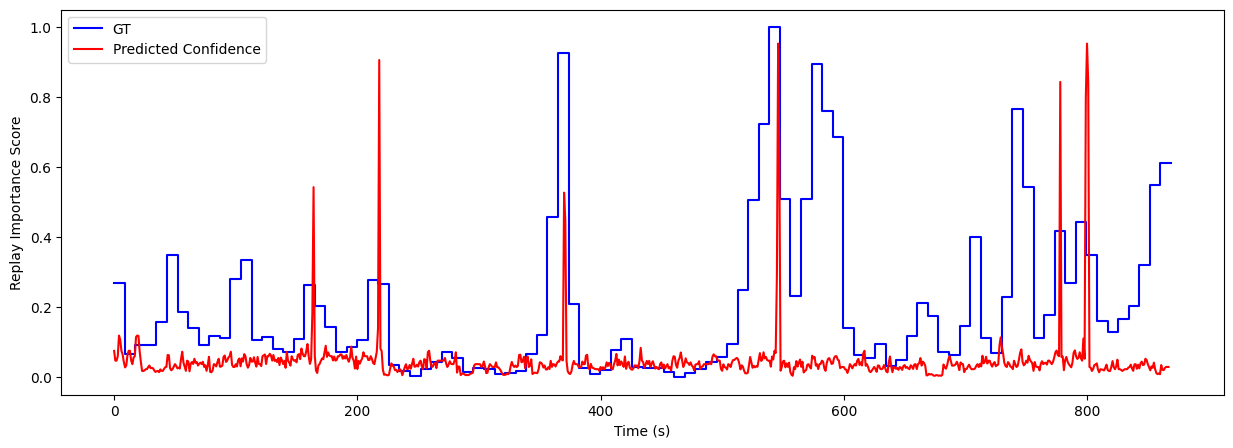

In [12]:
plt.figure(figsize=(15, 5))
plt.step(times, values, where="post", label="Heatmap Values", color='b')
plt.plot(torch.hstack(all_hits_confs).cpu().to(torch.float16), color='r')
plt.xlabel("Time (s)")
plt.ylabel("Replay Importance Score")
plt.legend(['GT', 'Predicted Confidence'])

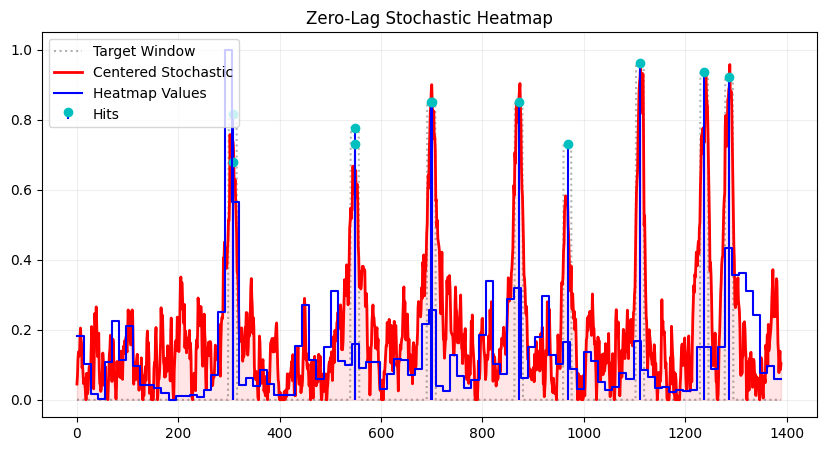

In [71]:
import torch
import matplotlib.pyplot as plt

def centered_stochastic_process(length, hits_indices, hits_confs, theta=0.2, sigma=0.1):
    """
    Runs a stochastic process forward and backward to create a 
    centered, organic heatmap without lag.
    """
    # 1. Create the "Target" (The Magnet)
    # We create a window around the hit so the process has time to rise and fall
    target_mu = torch.zeros(length)
    half_width = 8  # How wide the "magnetic field" is around a hit
    
    for idx, conf in zip(hits_indices, hits_confs):
        # Center the target window exactly on the hit index
        start = max(0, int(idx) - half_width)
        end = min(length, int(idx) + half_width)
        target_mu[start:end] = torch.max(target_mu[start:end], conf)

    # 2. Define the Solver (Single Direction)
    def solve_ou_process(target_array):
        trajectory = torch.zeros(length)
        x = 0.0
        # Pre-generate noise for speed
        noise = torch.randn(length) * sigma
        
        for t in range(1, length):
            prev_x = trajectory[t-1]
            mu = target_array[t]
            
            # dX = theta * (Target - Current) + Noise
            dx = theta * (mu - prev_x) + noise[t]
            
            x = prev_x + dx
            x = max(0.0, x) # Clamp negative values
            trajectory[t] = x
        return trajectory

    # 3. Run Forward (Lags to the Right)
    forward_path = solve_ou_process(target_mu)
    
    # 4. Run Backward (Lags to the Left)
    # Flip target -> Solve -> Flip result back
    backward_path = solve_ou_process(torch.flip(target_mu, [0]))
    backward_path = torch.flip(backward_path, [0])
    
    # 5. Combine
    # Averaging cancels the phase shift (lag)
    centered_path = (forward_path + backward_path) / 2
    
    # Normalize height to match the original confidence (optional)
    if centered_path.max() > 0:
        centered_path = centered_path / centered_path.max() * target_mu.max()
        
    return centered_path, target_mu

# --- Usage ---
length = int(data[-1]["end_time"])
hits = torch.hstack(all_hits).to(torch.float16)
confs = torch.hstack(all_hits_confs).to(torch.float16)

# Apply Bidirectional Process
y_centered, target = centered_stochastic_process(length, hits, confs, theta=0.1, sigma=0.05)

# --- Plotting ---
x_axis = torch.arange(length)
plt.figure(figsize=(10, 5))
# 1. Plot the "Target" (The invisible box forcing the shape)
plt.plot(x_axis, target, 'k:', alpha=0.3, label="Target Window")

# 2. Plot the Result
plt.plot(x_axis, y_centered, 'r', linewidth=2, label="Centered Stochastic")
plt.fill_between(x_axis, y_centered, color='red', alpha=0.1)

# 3. Plot the Hit Markers
plt.stem(hits, confs, linefmt='b-', markerfmt='co', basefmt=" ", label="Hits")
plt.step(times, values, where="post", label="Heatmap Values", color='b')
plt.title("Zero-Lag Stochastic Heatmap")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

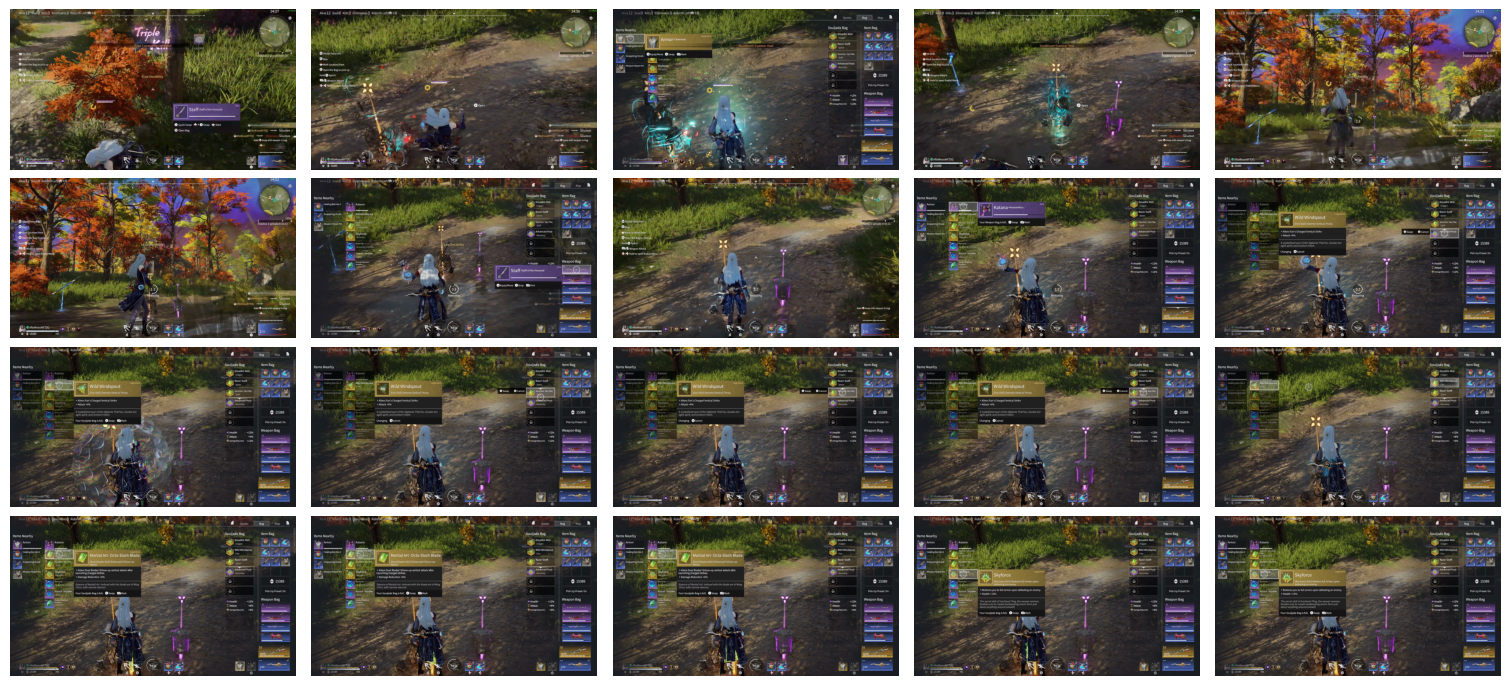

In [15]:
plot_images_grid(hit_frames_segments[(680, 720)], cols=5)

In [ ]:
#dict_keys([(300, 320), (540, 560), (860, 880), (960, 980), (1100, 1120)])

In [82]:
final_model = AutoModelForVision2Seq.from_pretrained(
            "Qwen/Qwen3-VL-8B-Instruct", 
            device_map="auto", 
            dtype=torch.bfloat16,
            trust_remote_code=True).eval()
final_tokenizer = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct", pad_token='<|endoftext|>')
final_model = QwenVLWrapper(final_model, final_tokenizer)

PROMPT = """
Act as a world-class Esports Shoutcaster (like for Dota 2). 
Your job is to hype up the audience for the game Naraka Bladepoint!

Guidelines:
1. SCREAM (use caps) for big moments like 'Double Kill' or big hits.
2. Focus strictly on the ACTION and MECHANICS. Don't describe the colors of the trees.
3. Use gamer terminology: "Clutch," "Melted," "Jukes," "Frame perfect," "Loadout swap."
4. When the player opens the inventory, comment on their build strategy briefly, don't list every item.
5. Keep it punchy! Short sentences! Fast pace!
"""

msgs = [
            {
                "role": "user", 
                "content": [
                    {
                    "type": "video",
                    "video": list(hit_frames_segments.values())[0],
                    "total_pixels": 20480 * 32 * 32, 
                    "min_pixels": 64 * 32 * 32, 
                    "max_frames": 2048,
                    'sample_fps': 1
                    },
                    {"type": "text", "text": PROMPT},
                ]
            },
        ]
    
answer = final_model.chat(
            image=None,
            msgs=msgs,
            tokenizer=final_tokenizer,
            sampling=False,
            temperature=0.0,
            max_slice_nums=1,
            use_image_id=False
    )
print(answer)

[2026-01-29 16:02:25] INFO modeling.py:989: We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

CLUTCH! DOUBLE KILL! THAT’S A RAGE CONVERSION INCREASED!

HE’S MELTING THE ENEMY LIKE A HOT CANDLE! FRAME PERFECT JUKES AND THAT BLADE IS A DANCE OF DEATH!

LOADOUT SWAP? HE’S GOT THE RIGHT STUFF IN THE BAG — HEALING, DAMAGE, AND THAT FAN IS A GLITCH IN THE MATRIX!

HE’S ON A KILL STREAK! THIS ISN’T JUST A GAME — THIS IS A BATTLE OF WILLS!

HE’S GOT THE MAP, THE WEAPONS, AND THE MOOD! THIS ISN’T A WALK IN THE PARK — THIS IS A WALK IN THE BLADES!

HE’S GOT THE EDGE — AND HE’S USING IT LIKE A SWORD THROUGH THE SKY!


In [77]:
USE_BACKBONE = "QWEN"

print("Loading Final Caption Model (QWEN3-VL)...")
final_model = AutoModelForVision2Seq.from_pretrained(
            "Qwen/Qwen3-VL-8B-Instruct", 
            device_map="auto", 
            dtype=torch.bfloat16,
            trust_remote_code=True).eval()
final_tokenizer = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct", pad_token='<|endoftext|>')
final_model = QwenVLWrapper(final_model, final_tokenizer)

SCORING_PROMPT = """
Analyze the audio context and gameplay segment and provide an EXPERT gameplay commentary for the given action video game!
"""

target_sr = 16000
resampler = T.Resample(orig_freq=sample_rate, new_freq=target_sr)

for keys, hit_frames in hit_frames_segments.items():
    start, end = keys
    waveform, sr = torchaudio.load(
            video_path,
            frame_offset=start * sample_rate,
            num_frames=int((end - start) * sample_rate),
    )
    waveform = resampler(waveform)
    audio_numpy = waveform[0].numpy()
    audio_input = {
    "array": audio_numpy,
    "sampling_rate": target_sr
    }
    
    result = asr_pipeline(
        audio_input,
        batch_size=8,
        return_timestamps=False,
        chunk_length_s=20,
        generate_kwargs={"language": "english"}
    )
    transcript = result['text'].strip()
    #captions = hit_frames_captions[keys]
    #ENHANCED_PROMPT = f"VISUAL CONTEXT: {captions}, AUDIO CONTEXT: The game announcer/characters said:{transcript}" + SCORING_PROMPT
    ENHANCED_PROMPT = f"AUDIO CONTEXT: The game announcer/characters said:{transcript}" + SCORING_PROMPT

    if "Mini" in USE_BACKBONE:
        msgs = [{
                    'role': 'user', 
                    #'content': frames + ["Analyze these frames for text banners or UI notifications indicating player achievements. \
                    #                    Specifically look for keywords like 'First Blood', 'Double Kill', 'Triple Kill', 'Quadra Kill', or 'Invincible'. \
                    #                    Does this event contain a significant combat achievement? STRICTLY answer only Yes or No."]
                    'content': hit_frames + [ENHANCED_PROMPT]
                }]
    else:
        msgs = [
            {
                "role": "user", 
                "content": [
                    {
                    "type": "video",
                    "video": hit_frames,
                    "total_pixels": 20480 * 32 * 32, 
                    "min_pixels": 64 * 32 * 32, 
                    "max_frames": 2048,
                    'sample_fps': 1
                    },
                    {"type": "text", "text": ENHANCED_PROMPT},
                ]
            },
        ]
    
    answer = final_model.chat(
            image=None,
            msgs=msgs,
            tokenizer=final_tokenizer,
            sampling=False,
            temperature=0.0,
            max_slice_nums=1,
            use_image_id=False
    )
    print(result)
    print(answer)
    break

Loading Final Caption Model (QWEN3-VL)...


[2026-01-29 15:48:53] INFO modeling.py:989: We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


TypeError: can only concatenate str (not "list") to str

In [ ]:
hit_frames_segments.keys()

In [15]:
target_sr = 16000

resampler = T.Resample(orig_freq=sample_rate, new_freq=target_sr)
waveform = resampler(waveform)
audio_numpy = waveform[0].numpy()

pipeline_input = {
    "array": audio_numpy,
    "sampling_rate": sample_rate
}

result = asr_pipeline(
    pipeline_input,
    batch_size=8,
    return_timestamps=True,
    chunk_length_s=30,
    generate_kwargs={"language": "english"} # Optional: Force English if known
)
print(result)

Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


{'text': ' Oh, my God.', 'chunks': [{'timestamp': (0.0, 7.26), 'text': ' Oh, my God.'}]}


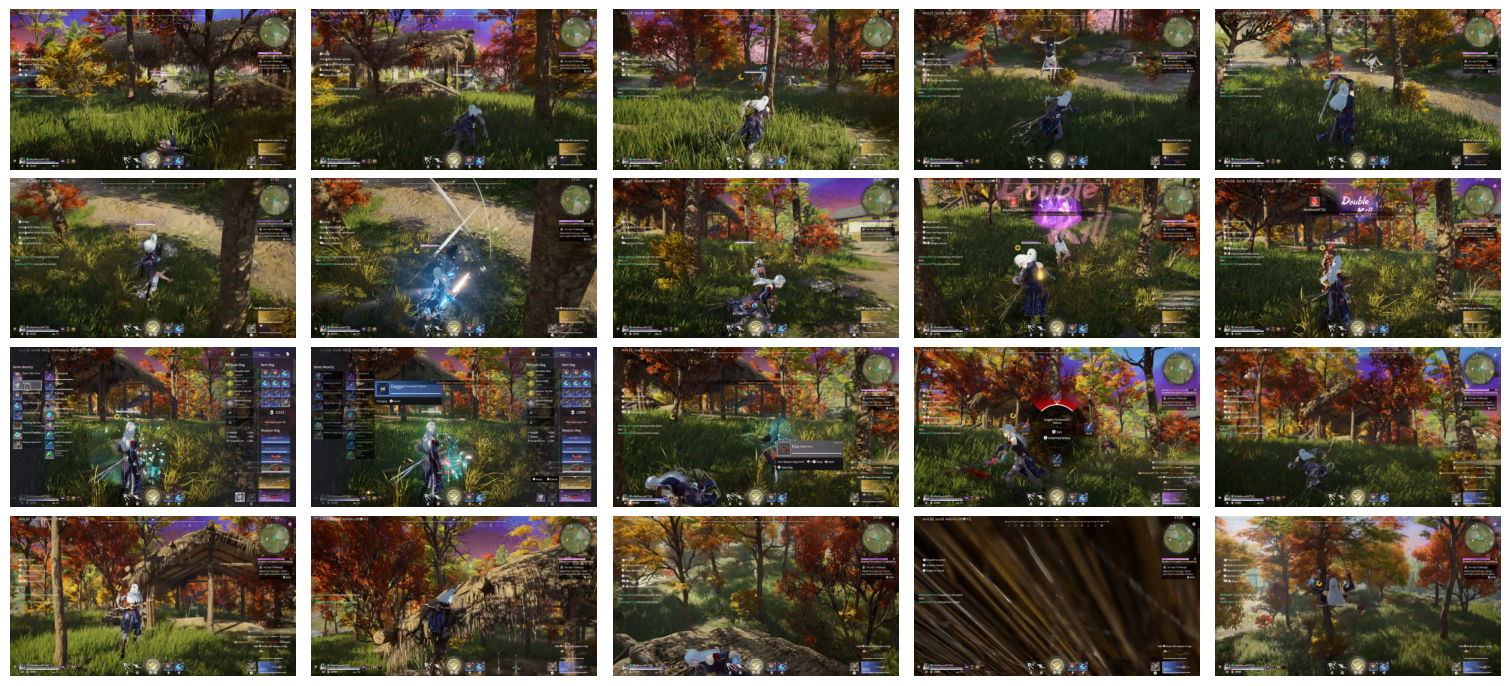

In [74]:
plot_images_grid(hit_frames_segments[(540, 560)], cols=5)

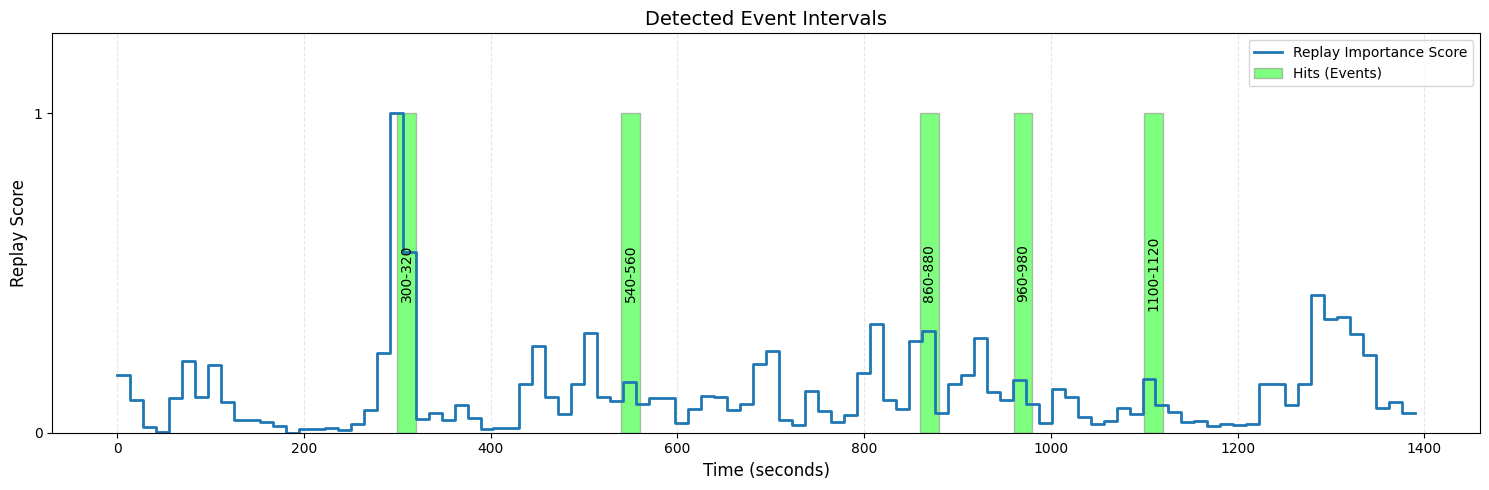

In [16]:
# 1. Setup Data
hit_segments = list(hit_frames_segments.keys())

# 2. Initialize Plot
fig, ax = plt.subplots(figsize=(15, 5))

# A. Plot the Blue Line (Replay Score)
# 'where="post"' gives that squared-off "step" look
ax.step(times, values, where='post', label='Replay Importance Score', linewidth=2)

# B. Plot the Green Bars (Hits)
for i, (start, end) in enumerate(hit_segments):
    width = end - start
    
    # Plot the bar
    ax.bar(x=start, height=1.0, width=width, align='edge', 
           color='lime', edgecolor='gray', alpha=0.5, 
           label='Hits (Events)' if i == 0 else "")

    # Add the text label inside the bar (Rotated 90 degrees)
    ax.text(x=start + width/2, y=0.5, s=f"{start}-{end}", 
            rotation=90, ha='center', va='center', fontsize=10)

# 3. Formatting
ax.set_title("Detected Event Intervals", fontsize=14)
ax.set_xlabel("Time (seconds)", fontsize=12)
ax.set_ylabel("Replay Score", fontsize=12)
ax.set_ylim(0, 1.25)
ax.set_yticks([0, 1])

# Add grid and legend
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()